# Data Load

Pull F1 timing + telemetry via FastF1. First run downloads to `../cache/`.

In [1]:
import fastf1
import pandas as pd
import numpy as np

# enable local cache (gitignored)
fastf1.Cache.enable_cache('../cache')

## Load one session

Session types: `FP1` `FP2` `FP3` `Q` `R` (sprint: `S`, `SQ`).

In [2]:
session = fastf1.get_session(2024, 'Monza', 'R')
session.load()  # downloads timing, laps, telemetry, weather

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

## Laps

In [3]:
laps = session.laps
print(laps.shape)
laps.head()

(1008, 31)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:57:18.931000,LEC,16,0 days 00:01:28.179000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:29.989000,...,True,Ferrari,0 days 00:55:50.494000,2024-09-01 13:03:34.413,1,2.0,False,,False,False
1,0 days 00:58:44.327000,LEC,16,0 days 00:01:25.396000,2.0,1.0,NaT,NaT,0 days 00:00:27.707000,0 days 00:00:29.265000,...,True,Ferrari,0 days 00:57:18.931000,2024-09-01 13:05:02.850,1,2.0,False,,False,True
2,0 days 01:00:09.506000,LEC,16,0 days 00:01:25.179000,3.0,1.0,NaT,NaT,0 days 00:00:27.679000,0 days 00:00:29.001000,...,True,Ferrari,0 days 00:58:44.327000,2024-09-01 13:06:28.246,1,2.0,False,,False,True
3,0 days 01:01:34.316000,LEC,16,0 days 00:01:24.810000,4.0,1.0,NaT,NaT,0 days 00:00:27.653000,0 days 00:00:28.883000,...,True,Ferrari,0 days 01:00:09.506000,2024-09-01 13:07:53.425,1,2.0,False,,False,True
4,0 days 01:02:58.919000,LEC,16,0 days 00:01:24.603000,5.0,1.0,NaT,NaT,0 days 00:00:27.630000,0 days 00:00:28.790000,...,True,Ferrari,0 days 01:01:34.316000,2024-09-01 13:09:18.235,1,2.0,False,,False,True


In [4]:
# columns available
list(laps.columns)

['Time',
 'Driver',
 'DriverNumber',
 'LapTime',
 'LapNumber',
 'Stint',
 'PitOutTime',
 'PitInTime',
 'Sector1Time',
 'Sector2Time',
 'Sector3Time',
 'Sector1SessionTime',
 'Sector2SessionTime',
 'Sector3SessionTime',
 'SpeedI1',
 'SpeedI2',
 'SpeedFL',
 'SpeedST',
 'IsPersonalBest',
 'Compound',
 'TyreLife',
 'FreshTyre',
 'Team',
 'LapStartTime',
 'LapStartDate',
 'TrackStatus',
 'Position',
 'Deleted',
 'DeletedReason',
 'FastF1Generated',
 'IsAccurate']

## Weather

In [5]:
session.weather_data.head()

,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,0 days 00:00:26.141000,33.2,38.0,993.8,False,52.1,318,0.7
1,0 days 00:01:26.139000,33.2,37.0,993.9,False,52.1,207,1.0
2,0 days 00:02:26.141000,33.2,37.0,993.9,False,52.8,230,1.3
3,0 days 00:03:26.146000,33.2,36.0,993.8,False,52.8,200,0.7
4,0 days 00:04:26.151000,33.3,36.0,993.8,False,52.8,182,0.8


## Telemetry for one driver

In [6]:
ver = laps.pick_drivers('VER').pick_fastest()
tel = ver.get_telemetry()
print(tel.shape)
tel[['Distance', 'Speed', 'Throttle', 'Brake', 'nGear', 'X', 'Y']].head()

(632, 18)


,Distance,Speed,Throttle,Brake,nGear,X,Y
2,0.266665,316.542500,100.0,False,8,-1376.705009,-710.765951
3,5.653889,317.000000,100.0,False,8,-1372.727497,-664.290235
4,17.685200,317.755556,100.0,False,8,-1363.000000,-553.000000
5,30.097292,318.533333,100.0,False,8,-1352.000000,-429.000000
6,37.553889,319.000000,100.0,False,8,-1345.615497,-354.485258


## Lap time vs tyre age

Is data usable for modeling?

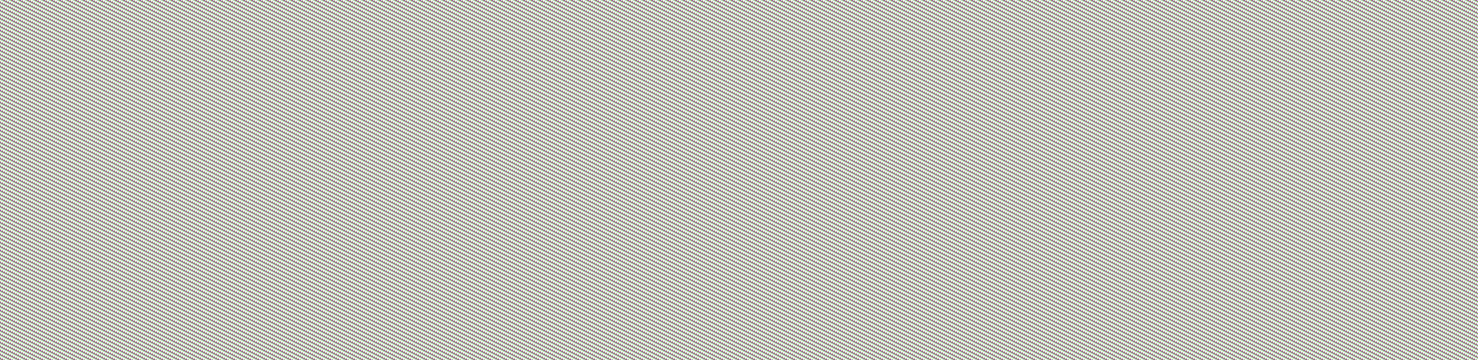

In [7]:
import plotly.express as px

df = laps[['Driver', 'LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint']].copy()
df = df.dropna(subset=['LapTime'])
df['LapTime_s'] = df['LapTime'].dt.total_seconds()

ver_laps = df[df['Driver'] == 'VER']
fig = px.scatter(ver_laps, x='TyreLife', y='LapTime_s', color='Compound',
                 title='VER lap time vs tyre life - Monza 2024')
fig.show()